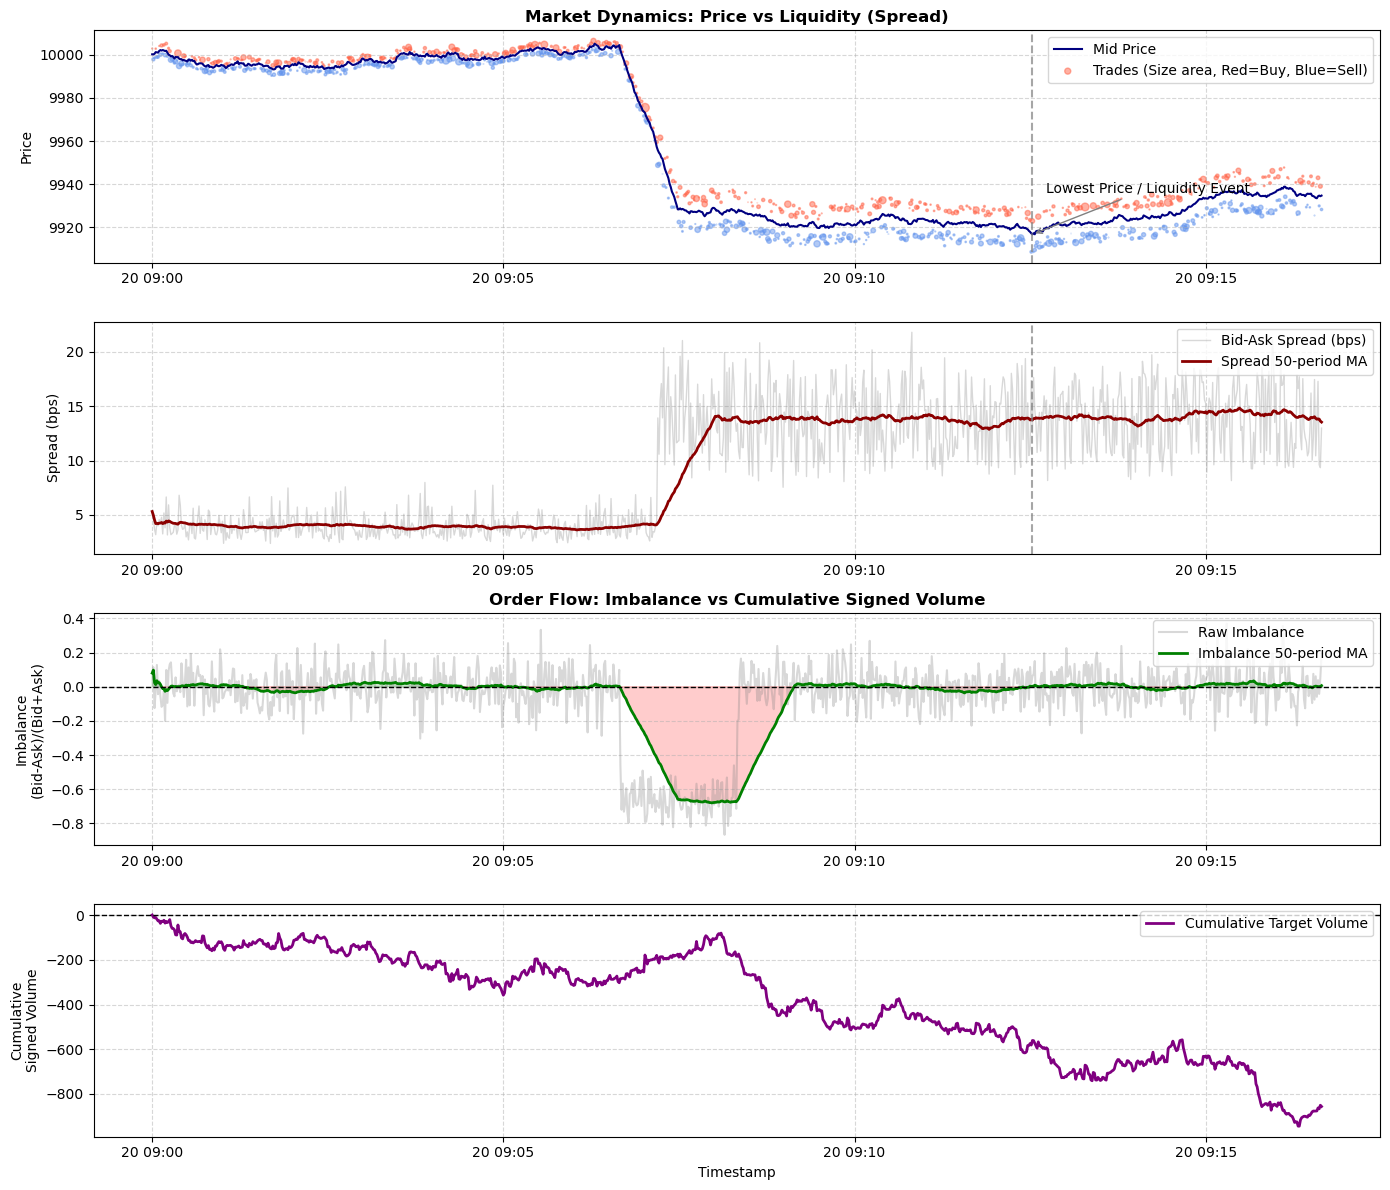

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. dfが存在しない場合のみダミーデータを生成する
if 'df' not in locals() and 'df' not in globals():
    np.random.seed(42)
    n = 1000
    
    # タイムスタンプ
    timestamps = pd.date_range("2026-03-20 09:00:00", periods=n, freq="S")
    
    # ミッドプライスのランダムウォーク（トレンドとショックを追加）
    returns = np.random.normal(0, 0.5, n)
    returns[400:450] -= 1.5 # ネガティブショック
    mid_price = 10000 + np.cumsum(returns)
    
    # スプレッド（ショック時に拡大させる）
    base_spread = np.random.lognormal(mean=0.5, sigma=0.5, size=n)
    shock_spread = np.where((mid_price < mid_price.mean()), np.random.uniform(5, 15, n), 0)
    bid_ask_spread_bps = base_spread + shock_spread + 2.0
    
    # トレード価格（ミッドプライスに対してスプレッドの半分をランダムに加減）
    is_buy = np.random.choice([1, -1], size=n, p=[0.45, 0.55]) # 売り優勢のダミー
    trade_price = mid_price + (is_buy * (bid_ask_spread_bps / 10000 * mid_price) / 2)
    
    # 板の厚みとインバランス
    bid_depth = np.random.poisson(50, n)
    ask_depth = np.random.poisson(50, n)
    # ショック時はBidが薄くなる
    bid_depth[400:500] = np.random.poisson(10, 100)
    order_imbalance = (bid_depth - ask_depth) / (bid_depth + ask_depth)
    
    # トレードサイズとSigned Volume
    trade_size = np.random.exponential(scale=10, size=n)
    signed_volume = trade_size * is_buy
    
    df = pd.DataFrame({
        'timestamp': timestamps,
        'mid_price': mid_price,
        'trade_price': trade_price,
        'trade_size': trade_size,
        'bid_ask_spread_bps': bid_ask_spread_bps,
        'bid_depth': bid_depth,
        'ask_depth': ask_depth,
        'signed_volume': signed_volume,
        'order_imbalance': order_imbalance
    })
    df.set_index('timestamp', inplace=True)
else:
    # 既存のdfが存在する場合、インデックスがtimestampでなければセット
    if 'timestamp' in df.columns:
        df = df.set_index('timestamp')

# --- 2. 可視化の実行 ---

plt.rcParams["font.size"] = 10
fig = plt.figure(figsize=(14, 12))

# --- 第1案：価格推移と流動性悪化（スプレッド） ---
# 上段：価格
ax1 = plt.subplot(4, 1, 1)
ax1.plot(df.index, df['mid_price'], label='Mid Price', color='navy', linewidth=1.5)
ax1.scatter(df.index, df['trade_price'], c=np.where(df['signed_volume']>0, 'tomato', 'cornflowerblue'), 
            s=df['trade_size'] * 0.5, alpha=0.5, label='Trades (Size area, Red=Buy, Blue=Sell)')
ax1.set_title('Market Dynamics: Price vs Liquidity (Spread)', fontweight='bold')
ax1.set_ylabel('Price')
ax1.legend(loc='upper right')
ax1.grid(True, linestyle='--', alpha=0.5)

# 注目イベント（ボラティリティ上昇エリア）のハイライト例
# dummyデータに基づき最も価格が急落した地点等をハイライト（実際は特定のイベント時間を指定）
event_idx = df['mid_price'].idxmin()
ax1.axvline(event_idx, color='gray', linestyle='--', alpha=0.7)
ax1.annotate('Lowest Price / Liquidity Event', xy=(event_idx, df.loc[event_idx, 'mid_price']),
             xytext=(10, 30), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='gray'))

# 下段：スプレッド
ax2 = plt.subplot(4, 1, 2, sharex=ax1)
# 移動平均の計算（ウィンドウはサンプル数の約5%）
window = max(5, len(df) // 20)
df['spread_ma'] = df['bid_ask_spread_bps'].rolling(window=window, min_periods=1).mean()

ax2.plot(df.index, df['bid_ask_spread_bps'], label='Bid-Ask Spread (bps)', color='gray', alpha=0.3, linewidth=1)
ax2.plot(df.index, df['spread_ma'], label=f'Spread {window}-period MA', color='darkred', linewidth=2)
ax2.set_ylabel('Spread (bps)')
ax2.legend(loc='upper right')
ax2.axvline(event_idx, color='gray', linestyle='--', alpha=0.7)
ax2.grid(True, linestyle='--', alpha=0.5)

# --- 第2案：オーダーフローの偏りと累積約定ボリューム ---
# 上段：オーダーインバランス
ax3 = plt.subplot(4, 1, 3, sharex=ax1)
df['oi_ma'] = df['order_imbalance'].rolling(window=window, min_periods=1).mean()

ax3.plot(df.index, df['order_imbalance'], color='gray', alpha=0.3, label='Raw Imbalance')
ax3.plot(df.index, df['oi_ma'], color='green', linewidth=2, label=f'Imbalance {window}-period MA')
ax3.axhline(0, color='black', linewidth=1, linestyle='--')
ax3.fill_between(df.index, df['oi_ma'], 0, where=(df['oi_ma'] > 0), color='green', alpha=0.2)
ax3.fill_between(df.index, df['oi_ma'], 0, where=(df['oi_ma'] < 0), color='red', alpha=0.2)
ax3.set_title('Order Flow: Imbalance vs Cumulative Signed Volume', fontweight='bold')
ax3.set_ylabel('Imbalance\n(Bid-Ask)/(Bid+Ask)')
ax3.legend(loc='upper right')
ax3.grid(True, linestyle='--', alpha=0.5)

# 下段：累積Signed Volume
ax4 = plt.subplot(4, 1, 4, sharex=ax1)
df['cum_signed_volume'] = df['signed_volume'].cumsum()
ax4.plot(df.index, df['cum_signed_volume'], color='purple', linewidth=2, label='Cumulative Target Volume')
ax4.set_ylabel('Cumulative\nSigned Volume')
ax4.set_xlabel('Timestamp')
ax4.legend(loc='upper right')
ax4.axhline(df['cum_signed_volume'].iloc[0], color='black', linewidth=1, linestyle='--')
ax4.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [3]:
import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# 1. dfが存在しない場合のみダミーデータを生成する
if 'df' not in locals() and 'df' not in globals():
    np.random.seed(42)
    n = 2000
    
    # タイムスタンプ
    timestamps = pd.date_range("2026-03-20 09:00:00", periods=n, freq="S")
    
    # 特徴量の生成
    mid_price = 10000 + np.cumsum(np.random.normal(0, 0.5, n))
    spread_bps = np.random.lognormal(mean=0.5, sigma=0.5, size=n) + 2.0
    depth_total = np.random.poisson(100, n)
    signed_volume = np.random.normal(0, 10, n)
    order_imbalance = np.random.uniform(-1, 1, n)
    realized_vol_5min = np.random.lognormal(mean=1, sigma=0.5, size=n)
    
    # リターン計算（本来は価格から計算しますが、今回は単純に生成）
    lagged_return_1min = np.random.normal(0, 0.001, n)
    future_mid_return_1min = 0.5 * order_imbalance - 0.2 * lagged_return_1min + np.random.normal(0, 0.005, n)
    future_mid_return_5min = 0.8 * future_mid_return_1min + np.random.normal(0, 0.01, n)
    
    df = pd.DataFrame({
        'timestamp': timestamps,
        'mid_price': mid_price,
        'future_mid_return_1min': future_mid_return_1min,
        'future_mid_return_5min': future_mid_return_5min,
        'spread_bps': spread_bps,
        'depth_total': depth_total,
        'signed_volume': signed_volume,
        'order_imbalance': order_imbalance,
        'realized_vol_5min': realized_vol_5min,
        'lagged_return_1min': lagged_return_1min
    })
    df.set_index('timestamp', inplace=True)
else:
    # 今回のリクエストに必要な列が存在するか確認し、足りなければ生成
    required_cols = ['mid_price', 'future_mid_return_1min', 'future_mid_return_5min', 'spread_bps', 'depth_total', 'signed_volume', 'order_imbalance', 'realized_vol_5min', 'lagged_return_1min']
    missing_cols = [col for col in required_cols if col not in df.columns]
    
    if missing_cols:
        print(f"Adding missing columns with dummy data: {missing_cols}")
        n = len(df)
        np.random.seed(42)
        if 'future_mid_return_1min' in missing_cols:
            df['future_mid_return_1min'] = np.random.normal(0, 0.005, n)
        if 'future_mid_return_5min' in missing_cols:
             df['future_mid_return_5min'] = np.random.normal(0, 0.01, n)
        if 'spread_bps' in missing_cols:
             df['spread_bps'] = np.random.lognormal(mean=0.5, sigma=0.5, size=n) + 2.0
        if 'depth_total' in missing_cols:
             df['depth_total'] = np.random.poisson(100, n)
        if 'realized_vol_5min' in missing_cols:
             df['realized_vol_5min'] = np.random.lognormal(mean=1, sigma=0.5, size=n)
        if 'lagged_return_1min' in missing_cols:
             df['lagged_return_1min'] = np.random.normal(0, 0.001, n)
        if 'signed_volume' in missing_cols:
             df['signed_volume'] = np.random.normal(0, 10, n)
        if 'order_imbalance' in missing_cols:
             df['order_imbalance'] = np.random.uniform(-1, 1, n)

# --- 特徴量と目的変数の設定 ---
# 予測のターゲットを定義
target_col = 'future_mid_return_1min'

# 使用する特徴量
features = ['spread_bps', 'depth_total', 'signed_volume', 
            'order_imbalance', 'realized_vol_5min', 'lagged_return_1min']

# --- データの前処理と分割 ---
# 時系列データのため、ランダム分割は厳禁（リークの原因）。時間を基準に分割する。
# ここでは単純に最初80%をTrain、残り20%をValidationとする
split_idx = int(len(df) * 0.8)

train_df = df.iloc[:split_idx].copy()
val_df = df.iloc[split_idx:].copy()

# 欠損値の処理（時系列では前値補完などが基本だが、今回はドロップ）
train_df = train_df.dropna(subset=features + [target_col])
val_df = val_df.dropna(subset=features + [target_col])

X_train = train_df[features]
y_train = train_df[target_col]
X_val = val_df[features]
y_val = val_df[target_col]

# スケーリング（Trainの情報のみを使ってValをスケール）
# 外れ値に強いRobustScalerが本来は望ましいが、今回はStandardScalerで簡易実装
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# --- モデル学習と評価 ---
# ベースラインモデルとしてRidge回帰（L2正則化）を使用
# 多重共線性を緩和するため

print("--- Baseline Model: Ridge Regression ---")
model = Ridge(alpha=1.0)
model.fit(X_train_scaled, y_train)

# 予測
y_pred_train = model.predict(X_train_scaled)
y_pred_val = model.predict(X_val_scaled)

# 評価指標の計算
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_val = np.sqrt(mean_squared_error(y_val, y_pred_val))
r2_train = r2_score(y_train, y_pred_train)
r2_val = r2_score(y_val, y_pred_val)

print(f"Train RMSE: {rmse_train:.6f}, R2: {r2_train:.4f}")
print(f"Val   RMSE: {rmse_val:.6f}, R2: {r2_val:.4f}")

# 係数の確認
print("\nFeature Coefficients:")
for feat, coef in zip(features, model.coef_):
    print(f"  {feat}: {coef:.6f}")

Adding missing columns with dummy data: ['future_mid_return_1min', 'future_mid_return_5min', 'spread_bps', 'depth_total', 'realized_vol_5min', 'lagged_return_1min']
--- Baseline Model: Ridge Regression ---
Train RMSE: 0.004866, R2: 0.0197
Val   RMSE: 0.004832, R2: -0.0270

Feature Coefficients:
  spread_bps: 0.000050
  depth_total: 0.000106
  signed_volume: 0.000685
  order_imbalance: -0.000013
  realized_vol_5min: 0.000010
  lagged_return_1min: 0.000009


Generating dummy data for PM performance review...


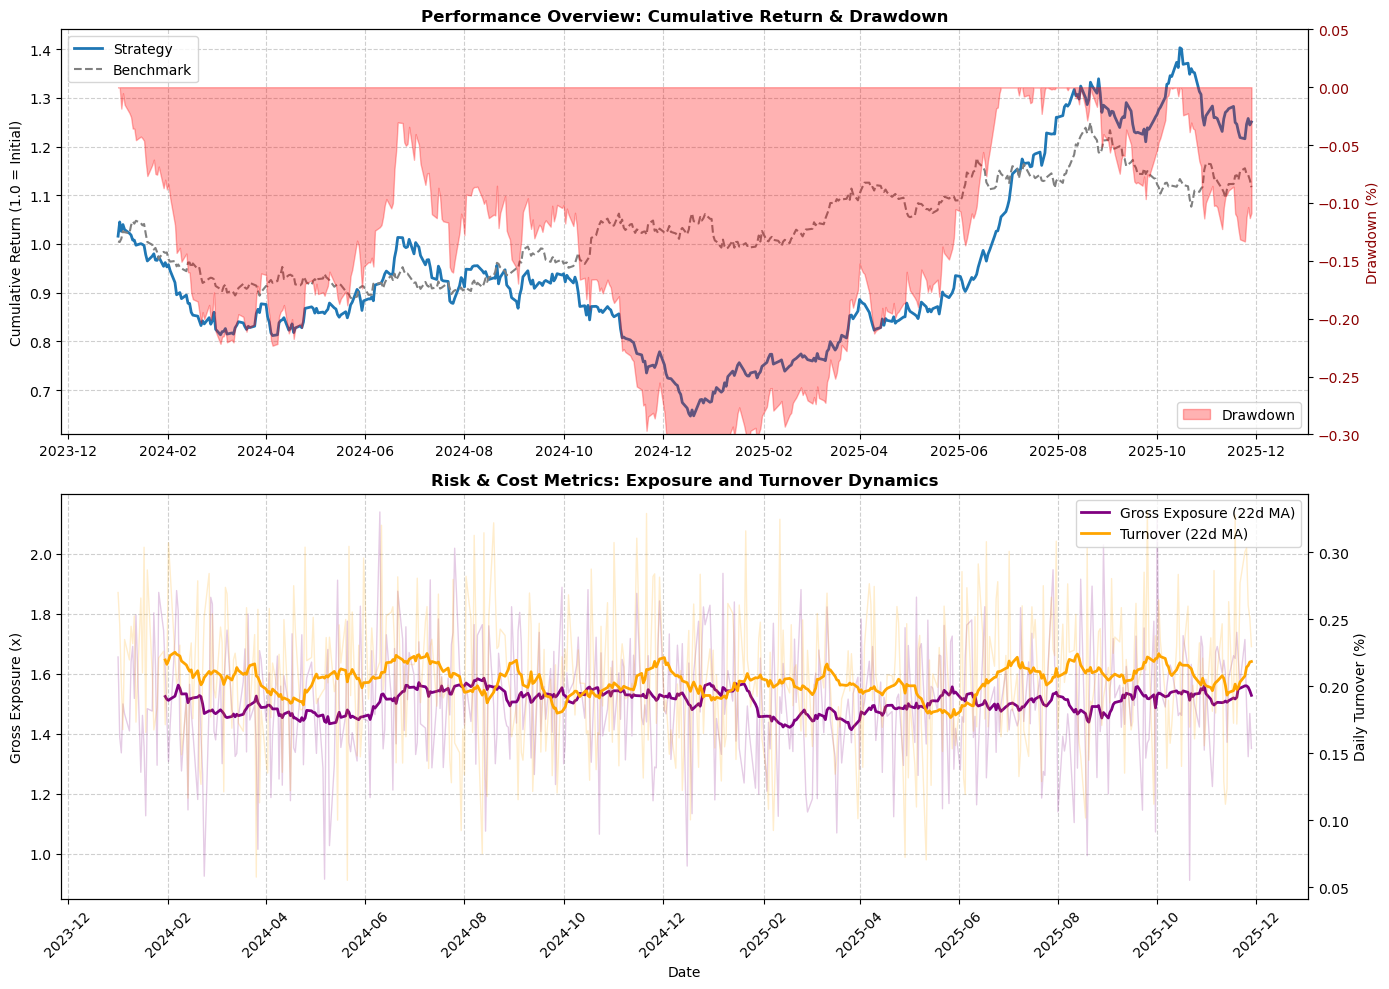

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. dfが存在しない場合のみダミーデータを生成する
# 今回は既存のdf（日次等ではないもの）がある可能性があるため、
# 指定された列がなければ新たにデータフレームを作成します。
required_pm_cols = ['date', 'strategy_return', 'benchmark_return', 'turnover', 'gross_exposure']
has_all_cols = 'df' in locals() and all(col in df.columns for col in required_pm_cols)

if not has_all_cols:
    print("Generating dummy data for PM performance review...")
    np.random.seed(42)
    days = 500
    dates = pd.date_range("2024-01-01", periods=days, freq="B") # 営業日
    
    # ベンチマークは全体的に右肩上がりだが変動あり
    benchmark_return = np.random.normal(0.0002, 0.01, days)
    
    # 戦略はアルファがあるが、時々ドローダウンがある
    # ベンチマークへのβを0.3程度持たせる
    alpha = np.random.normal(0.0005, 0.015, days)
    # 中盤でドローダウンをシミュレート
    alpha[200:250] -= 0.005 
    strategy_return = 0.3 * benchmark_return + alpha
    
    # トレード回転率（毎日平均20%前後）
    turnover = np.random.normal(0.2, 0.05, days)
    turnover = np.clip(turnover, 0.05, 0.5) # 極端な値を制限
    
    # グロスエクスポージャー（レバレッジ）（平均1.5倍前後）
    gross_exposure = np.random.normal(1.5, 0.2, days)
    
    pm_df = pd.DataFrame({
        'date': dates,
        'strategy_return': strategy_return,
        'benchmark_return': benchmark_return,
        'turnover': turnover,
        'gross_exposure': gross_exposure
    })
    pm_df.set_index('date', inplace=True)
else:
    pm_df = df.copy()
    if 'date' in pm_df.columns:
        pm_df = pm_df.set_index('date')
    # timestampインデックスの場合はdateとして扱う
    elif isinstance(pm_df.index, pd.DatetimeIndex):
        pass

# リターンの累積値を計算 (1を起点とする)
pm_df['cum_strategy'] = (1 + pm_df['strategy_return']).cumprod()
pm_df['cum_benchmark'] = (1 + pm_df['benchmark_return']).cumprod()

# ドローダウンの計算
pm_df['rolling_max'] = pm_df['cum_strategy'].cummax()
pm_df['drawdown'] = pm_df['cum_strategy'] / pm_df['rolling_max'] - 1.0


# --- 2. 可視化の実行 ---
plt.rcParams["font.size"] = 10
fig = plt.figure(figsize=(14, 10))

# ---------------------------------------------------------
# 【第1の図】累積リターンとドローダウンの統合チャート
# ---------------------------------------------------------
ax1 = plt.subplot(2, 1, 1)

# 累積リターン
ax1.plot(pm_df.index, pm_df['cum_strategy'], label='Strategy', linewidth=2)
ax1.plot(pm_df.index, pm_df['cum_benchmark'], label='Benchmark', linewidth=1.5, linestyle='--', color='gray')
ax1.set_ylabel('Cumulative Return (1.0 = Initial)')
ax1.set_title('Performance Overview: Cumulative Return & Drawdown', fontweight='bold', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper left')

# X軸の月次フォーマット
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

# ドローダウン（右軸）
ax1_twin = ax1.twinx()
ax1_twin.fill_between(pm_df.index, pm_df['drawdown'], 0, color='red', alpha=0.3, label='Drawdown')
ax1_twin.set_ylabel('Drawdown (%)', color='darkred')
ax1_twin.tick_params(axis='y', labelcolor='darkred')

# Y軸の範囲を調整して見やすくする
ax1_twin.set_ylim(-0.3, 0.05) # 最大30%のDDを想定。上部に余白を設ける
ax1_twin.legend(loc='lower right')

# ---------------------------------------------------------
# 【第2の図】リスク指標：グロスエクスポージャーと回転率の推移
# ---------------------------------------------------------
ax2 = plt.subplot(2, 1, 2, sharex=ax1)

# ボックスプロット風の表現の代わりに、22日（約1ヶ月）移動平均でトレンドを可視化
window = 22
pm_df['turnover_ma'] = pm_df['turnover'].rolling(window).mean()
pm_df['gross_ma'] = pm_df['gross_exposure'].rolling(window).mean()

# グロスエクスポージャー
p1, = ax2.plot(pm_df.index, pm_df['gross_ma'], color='purple', linewidth=2, label=f'Gross Exposure ({window}d MA)')
ax2.plot(pm_df.index, pm_df['gross_exposure'], color='purple', alpha=0.2, linewidth=1)
ax2.set_ylabel('Gross Exposure (x)')
ax2.set_xlabel('Date')
ax2.grid(True, linestyle='--', alpha=0.6)

# 回転率（右軸）
ax2_twin = ax2.twinx()
p2, = ax2_twin.plot(pm_df.index, pm_df['turnover_ma'], color='orange', linewidth=2, label=f'Turnover ({window}d MA)')
ax2_twin.plot(pm_df.index, pm_df['turnover'], color='orange', alpha=0.2, linewidth=1)
ax2_twin.set_ylabel('Daily Turnover (%)')

# 凡例を統合
lines = [p1, p2]
ax2.legend(lines, [l.get_label() for l in lines], loc='upper right')
ax2.set_title('Risk & Cost Metrics: Exposure and Turnover Dynamics', fontweight='bold', fontsize=12)

# X軸の回転
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

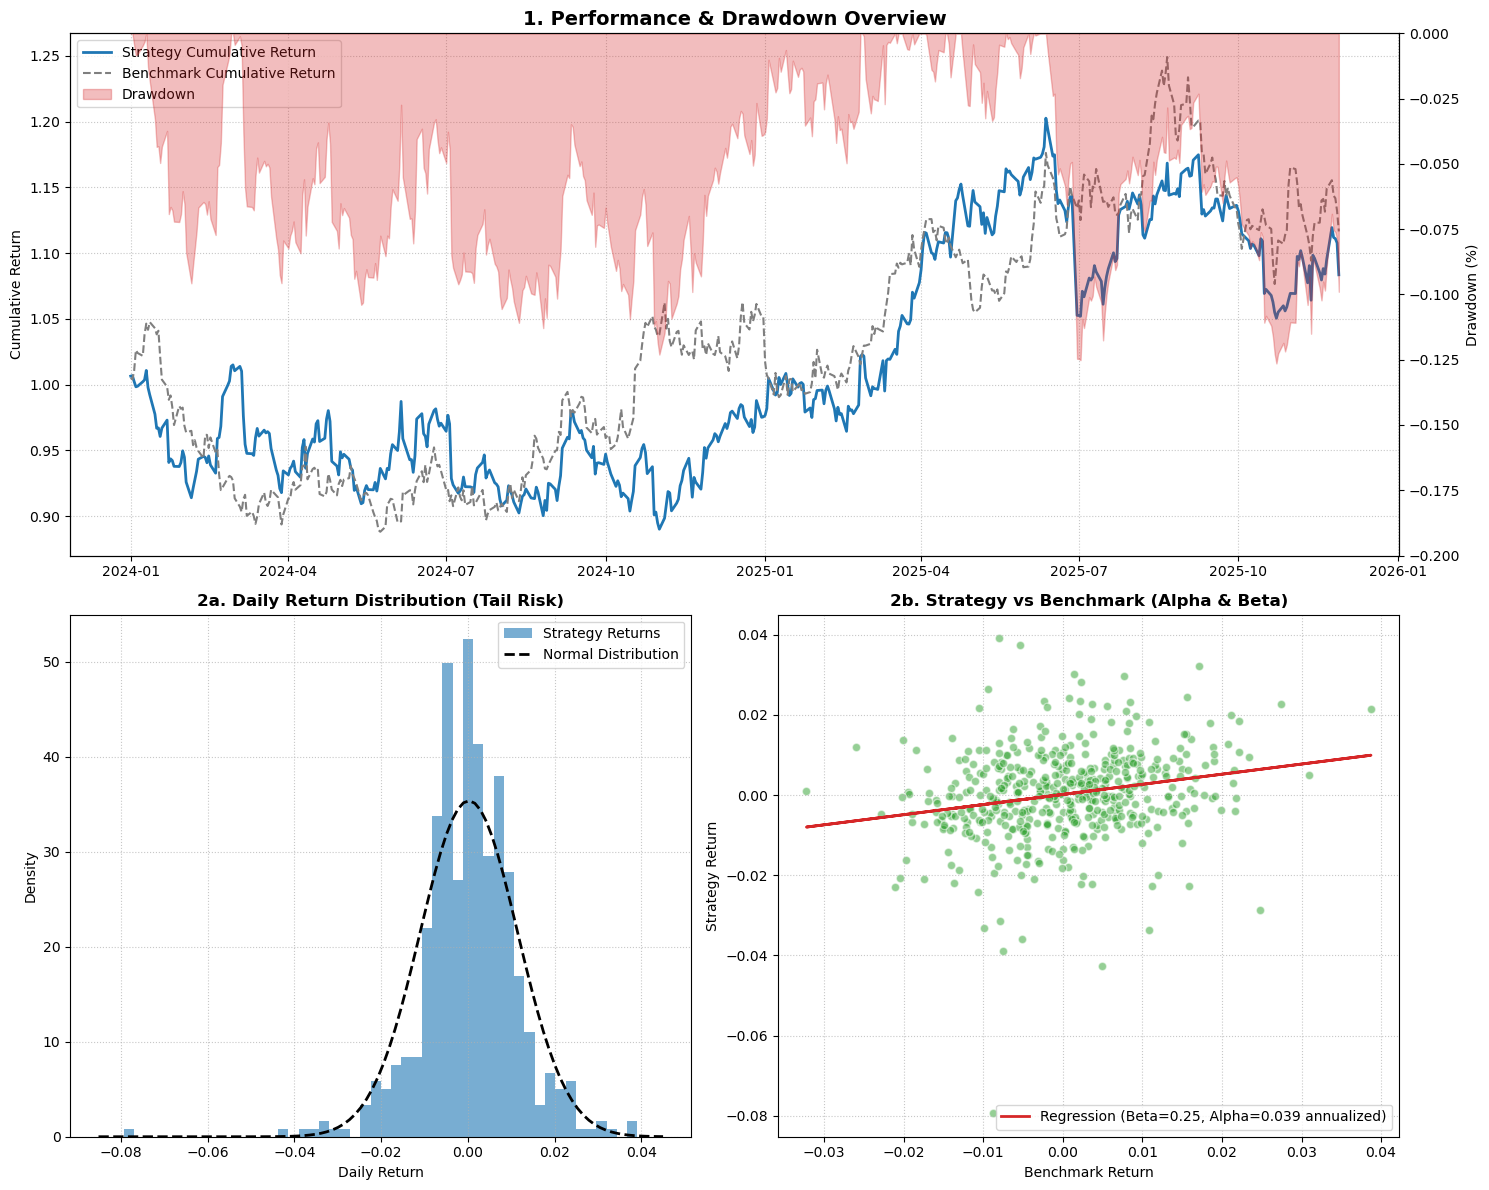

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

# 1. ダミーデータの生成 (既存のdfがない場合、または必要な列がない場合)
required_cols = ['date', 'strategy_return', 'benchmark_return', 'turnover', 'gross_exposure']
if 'df' not in locals() or not all(col in df.columns for col in required_cols):
    np.random.seed(42)
    dates = pd.date_range("2024-01-01", periods=500, freq="B")
    
    # ベンチマークのリターン（やや右肩上がり）
    benchmark_return = np.random.normal(0.0002, 0.01, len(dates))
    
    # 戦略のリターン（アルファ + ベータ + 独自ノイズ）
    # 意図的にファットテール（極端なマイナス）を少し混ぜる
    alpha = 0.0005
    beta = 0.3
    noise = np.random.standard_t(df=4, size=len(dates)) * 0.008 
    strategy_return = alpha + beta * benchmark_return + noise
    
    df = pd.DataFrame({
        'date': dates,
        'strategy_return': strategy_return,
        'benchmark_return': benchmark_return,
        'turnover': np.random.uniform(0.1, 0.5, len(dates)),
        'gross_exposure': np.random.normal(1.5, 0.2, len(dates))
    })
    df.set_index('date', inplace=True)
else:
    # 既存のdfを使用
    if 'date' in df.columns:
        df = df.set_index('date')

# 累積リターンとドローダウンの計算
df['cum_strategy'] = (1 + df['strategy_return']).cumprod()
df['cum_benchmark'] = (1 + df['benchmark_return']).cumprod()
df['rolling_max'] = df['cum_strategy'].cummax()
df['drawdown'] = df['cum_strategy'] / df['rolling_max'] - 1.0

# --- 2. 可視化の実行 ---
fig = plt.figure(figsize=(15, 12))

# -------- 図1: 累積リターンとドローダウン --------
ax1 = plt.subplot(2, 1, 1)
ax1.plot(df.index, df['cum_strategy'], label='Strategy Cumulative Return', color='C0', linewidth=2)
ax1.plot(df.index, df['cum_benchmark'], label='Benchmark Cumulative Return', color='C7', linestyle='--', linewidth=1.5)
ax1.set_title('1. Performance & Drawdown Overview', fontsize=14, fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.grid(True, linestyle=':', alpha=0.7)

# ドローダウン（右軸）
ax1_twin = ax1.twinx()
ax1_twin.fill_between(df.index, df['drawdown'], 0, color='C3', alpha=0.3, label='Drawdown')
ax1_twin.set_ylabel('Drawdown (%)')
ax1_twin.set_ylim(-max(0.2, abs(df['drawdown'].min()) * 1.5), 0) # 見栄えのためのスケール調整

# 凡例の統合
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

# -------- 図2: リターン分布とベンチマーク散布図 --------
# ヒストグラム
ax2 = plt.subplot(2, 2, 3)
ax2.hist(df['strategy_return'], bins=50, density=True, alpha=0.6, color='C0', label='Strategy Returns')

# 正規分布の近似線を引く（テールリスクの確認用）
xmin, xmax = ax2.get_xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, df['strategy_return'].mean(), df['strategy_return'].std())
ax2.plot(x, p, 'k', linewidth=2, linestyle='--', label='Normal Distribution')

ax2.set_title('2a. Daily Return Distribution (Tail Risk)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Daily Return')
ax2.set_ylabel('Density')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

# 散布図
ax3 = plt.subplot(2, 2, 4)
ax3.scatter(df['benchmark_return'], df['strategy_return'], alpha=0.5, color='C2', edgecolors='white')

# 回帰線（ベータの可視化）
slope, intercept, r_value, p_value, std_err = stats.linregress(df['benchmark_return'], df['strategy_return'])
ax3.plot(df['benchmark_return'], intercept + slope * df['benchmark_return'], color='C3', linewidth=2, 
         label=f'Regression (Beta={slope:.2f}, Alpha={intercept*252:.3f} annualized)')

ax3.set_title('2b. Strategy vs Benchmark (Alpha & Beta)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Benchmark Return')
ax3.set_ylabel('Strategy Return')
ax3.legend()
ax3.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()